# 10 — Evaluating Generative Models: FID and BLEU

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand what **FID** (Fréchet Inception Distance) measures and **compute a Fréchet distance** yourself on image sets of graded quality
- **Compute BLEU scores** with NLTK on generated-text examples of graded quality
- Interpret both metrics: what "lower FID" / "higher BLEU" actually certify — and what they miss

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 2 (holding out data to get an honest number) and Course 10 — Unit 1, lesson 09, whose side-by-side comparison needed a metric.

**Used later in:** Course 10 — Unit 2, lesson 06, which computes BLEU and perplexity on text you generate.

---

## Introduction

Looking at samples (example 09) does not scale. The field's standard automatic metrics are:

- **FID** for images: fit a Gaussian (mean μ, covariance Σ) to *feature vectors* of real images and of generated images, then compute the Fréchet distance
  **FID = ‖μ_r − μ_g‖² + Tr(Σ_r + Σ_g − 2(Σ_r Σ_g)^{1/2})** — lower is better.
  The "Inception" in the name: production FID extracts those features with a pretrained InceptionV3 network. To keep this notebook download-free, we use **PCA features on 8×8 digits instead of Inception features** — the Fréchet computation itself is *exactly* the real one, so we label our numbers "Fréchet distance (PCA features)", not official FID values.
- **BLEU** for text: modified n-gram precision of a candidate against reference texts, with a brevity penalty — between 0 and 1, higher is better.

---

## 🌍 Why this lesson exists — FID moved when nobody changed the model

Parmar, Zhang & Zhu (2022, arXiv 2104.11222) found that FID scores shift because of *image resizing implementations*: the resizers in common libraries alias, and — their most uncomfortable result — if you JPEG-compress your generated images to match training images that were themselves compressed, **FID improves**. Papers were being ranked on a number that moved with a preprocessing detail nobody reported. That is why the `clean-fid` package exists, and why "our FID is 12.3" is a meaningless sentence without the pipeline that produced it.

**What goes wrong without this:** you optimise what you measure. A team that reports FID and nothing else will, within a few months, have shipped the model with the better FID and the worse product — and will be unable to explain why users prefer the older one.


## Part 1 — Fréchet Distance on Image Sets of Graded Quality

The honest way to test a metric: feed it sets whose quality we already know, and check that it separates them sensibly — a real held-out set should score near 0, corrupted sets higher, and garbage highest. We compare four "generated" sets against a held-out real set:

1. **real** — a second sample of true digits (a perfect generator would look like this)
2. **blurred** — real digits, Gaussian-blurred
3. **noisy** — real digits + pixel noise
4. **noise** — pure random pixels (a worthless generator)


candidate set      Frechet distance (PCA features) — lower is better
real (held-out)          0.06
blurred                  2.29
noisy                    0.26
pure noise               3.82


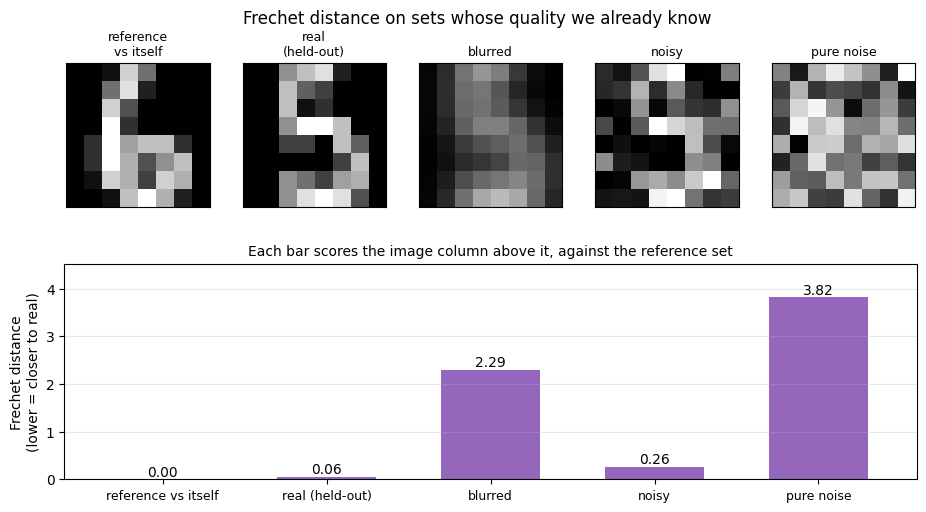


Read the table: a held-out real set scores near 0, corruption raises the
distance, and pure noise scores far worse — the ordering FID is built to give.


In [1]:
# WHAT/WHY: implement the exact FID formula (Frechet distance between
# Gaussian fits of feature vectors) and verify it separates image sets of
# KNOWN quality: real scores near 0, corrupted sets higher, pure noise worst.
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
from scipy.ndimage import gaussian_filter
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

rng = np.random.default_rng(0)

# ── Real digit images (1797 samples of 8×8 pixels, values 0..16) ──────────
digits = load_digits()
X = digits.images / 16.0                      # scale to [0, 1]
rng.shuffle(X)
real_ref, real_other = X[:800], X[800:1600]   # two disjoint real sets

# ── Candidate "generated" sets of graded (known) quality ──────────────────
blurred = np.stack([gaussian_filter(img, sigma=0.9) for img in real_other])
noisy   = np.clip(real_other + rng.normal(0, 0.25, real_other.shape), 0, 1)
noise   = rng.uniform(0, 1, real_other.shape)          # worthless generator

# ── Feature extractor: PCA fitted on real reference images ────────────────
# (Production FID uses InceptionV3's 2048-dim features here instead.)
pca = PCA(n_components=32).fit(real_ref.reshape(len(real_ref), -1))
def features(imgs):
    return pca.transform(imgs.reshape(len(imgs), -1))

# ── The FID formula, verbatim ─────────────────────────────────────────────
def frechet_distance(feat_real, feat_gen):
    mu_r, mu_g = feat_real.mean(0), feat_gen.mean(0)
    sigma_r = np.cov(feat_real, rowvar=False)
    sigma_g = np.cov(feat_gen,  rowvar=False)
    covmean = sqrtm(sigma_r @ sigma_g).real       # matrix square root
    return ((mu_r - mu_g) ** 2).sum() + np.trace(sigma_r + sigma_g - 2 * covmean)

# ── Score every candidate set against the real reference ──────────────────
feat_ref = features(real_ref)
results = {}
for name, imgs in [("real (held-out)", real_other), ("blurred", blurred),
                   ("noisy", noisy), ("pure noise", noise)]:
    results[name] = frechet_distance(feat_ref, features(imgs))

print("candidate set      Frechet distance (PCA features) — lower is better")
for name, val in results.items():
    print(f"{name:<18} {val:10.2f}")

# ── ONE figure: each set's image directly above its own score ─────────────
# Two separate figures (a row of images, then a bar chart) force the reader to
# match a picture to a bar by memory. Stacking them puts the evidence and the
# number in the same column.
# The reference set scored against ITSELF is included as the left-hand anchor:
# it is the floor of the scale, and without it "0.06" has nothing to mean.
# Mathematically this is exactly 0; sqrtm returns a tiny negative float, so we
# clamp it for display rather than printing a puzzling "-0.00" on the chart.
self_score = max(frechet_distance(feat_ref, feat_ref), 0.0)
panels = [("reference\nvs itself", real_ref, self_score),
          ("real\n(held-out)",     real_other, results["real (held-out)"]),
          ("blurred",              blurred,   results["blurred"]),
          ("noisy",                noisy,     results["noisy"]),
          ("pure noise",           noise,     results["pure noise"])]

fig = plt.figure(figsize=(11, 5.4))
gs = fig.add_gridspec(2, len(panels), height_ratios=[1, 1.5], hspace=0.32)
for k, (name, imgs, score) in enumerate(panels):
    ax = fig.add_subplot(gs[0, k])
    ax.imshow(imgs[0], cmap='gray', vmin=0, vmax=1)
    ax.set_title(name, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
axB = fig.add_subplot(gs[1, :])
xs = np.arange(len(panels))
colors = ['0.55'] + ['tab:purple'] * (len(panels) - 1)
axB.bar(xs, [p[2] for p in panels], color=colors, width=0.6)
for x, (_, _, score) in zip(xs, panels):
    axB.text(x, score, f"{score:.2f}", ha='center', va='bottom', fontsize=10)
axB.set_xticks(xs); axB.set_xticklabels([p[0].replace("\n", " ") for p in panels], fontsize=9)
axB.set_xlim(-0.6, len(panels) - 0.4)
axB.set_ylabel("Frechet distance\n(lower = closer to real)"); axB.margins(y=0.18)
axB.set_title("Each bar scores the image column above it, against the reference set", fontsize=10)
axB.grid(axis='y', alpha=0.3)
plt.suptitle("Frechet distance on sets whose quality we already know", fontsize=12)
plt.show()

print("\nRead the table: a held-out real set scores near 0, corruption raises the")
print("distance, and pure noise scores far worse — the ordering FID is built to give.")


**Read each bar against the image above it.** The leftmost bar is the reference set scored against itself: 0.00 by construction, the floor of this scale. Next to it, a *different* sample of genuinely real digits scores 0.06 — not zero, because 800 real images never have exactly the same mean and covariance as another 800, and that gap is the noise level of the measurement. Anything close to 0.06 is indistinguishable from real as far as this metric can tell.

From there the metric behaves: corrupt the images and the distance rises; use pure random pixels and it goes to 3.82, more than sixty times the real-vs-real gap. That ordering is the whole job FID was built to do, and here it does it.

**Now look at the ordering more carefully, because this is the lesson.** Blurred scores **2.29** and noisy scores **0.26** — the metric calls blur about nine times worse than speckle. Compare the two images above those bars and ask whether you agree. Most people find the noisy digit easier to read than the blurred one; the metric says the opposite, emphatically. Nothing is broken — the blur moved the feature distribution much further than the noise did — but the metric's idea of "worse" and a human's have just parted company by a factor of nine, on a test where we knew the answer in advance.

That is the honest use of this figure: FID orders *grossly* different quality reliably, and its fine-grained ordering encodes the feature extractor's priorities, not yours. Discussion question 1 is about what you do with that.

## Part 2 — BLEU on Text of Graded Quality

Same honest test for text: candidates whose quality ranking we know, scored against reference translations with NLTK's `sentence_bleu` (smoothing method 1, standard for short sentences).


In [2]:
# WHAT/WHY: compute real BLEU scores with NLTK on candidates of known,
# graded quality — from a perfect match down to unrelated text — and check
# the scores fall in that order.
%pip install nltk -q
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1   # avoids zero scores on short sentences

# ── One reference "translation" (tokenized) ───────────────────────────────
reference = [["the", "cat", "sat", "on", "the", "warm", "mat", "near", "the", "door"]]

# ── Candidates of graded quality, best to worst ───────────────────────────
candidates = {
    "exact match":     ["the", "cat", "sat", "on", "the", "warm", "mat", "near", "the", "door"],
    "close paraphrase":["the", "cat", "sat", "on", "the", "warm", "mat", "by",   "the", "door"],
    "partial overlap": ["a",   "cat", "was", "on", "the", "mat"],
    "unrelated":       ["quantum", "computing", "will", "change", "cryptography", "forever"],
}

# ── Score each candidate (4-gram BLEU, the standard) ──────────────────────
print("candidate           BLEU (0-1, higher is better)")
for name, cand in candidates.items():
    score = sentence_bleu(reference, cand, smoothing_function=smooth)
    print(f"{name:<19} {score:.4f}")

print("\nRead the scores: they fall exactly with quality. Note BLEU's limits — it")
print("rewards n-gram overlap with the reference, so a *valid* but differently")
print("worded output scores low; modern LLM evaluation adds semantic metrics")
print("(BERTScore, human/model grading) on top of BLEU.")



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


candidate           BLEU (0-1, higher is better)
exact match         1.0000
close paraphrase    0.7071
partial overlap     0.0527
unrelated           0.0000

Read the scores: they fall exactly with quality. Note BLEU's limits — it
rewards n-gram overlap with the reference, so a *valid* but differently
worded output scores low; modern LLM evaluation adds semantic metrics
(BERTScore, human/model grading) on top of BLEU.


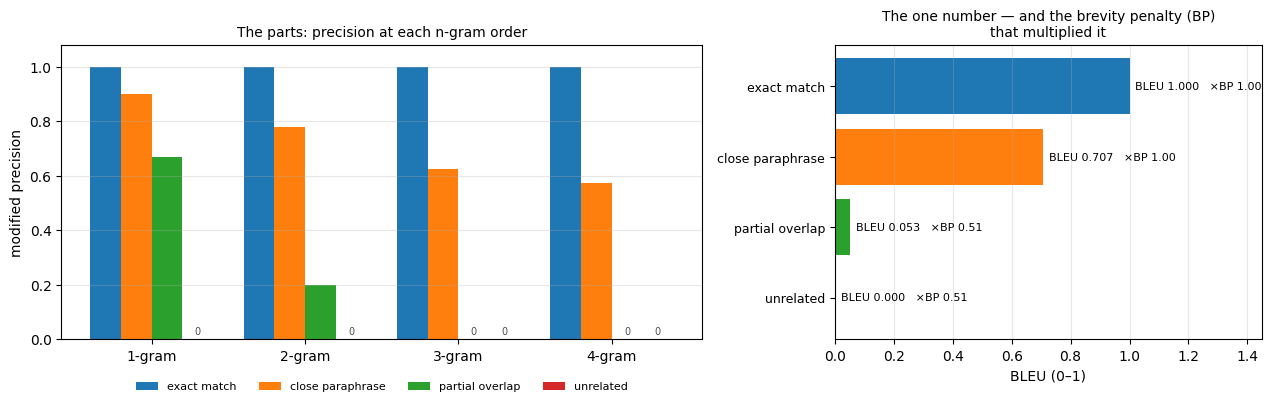

candidate           1-gram  2-gram  3-gram  4-gram   brevity penalty   BLEU
exact match           1.00    1.00    1.00    1.00           1.000   1.0000
close paraphrase      0.90    0.78    0.62    0.57           1.000   0.7071
partial overlap       0.67    0.20    0.00    0.00           0.513   0.0527
unrelated             0.00    0.00    0.00    0.00           0.513   0.0000


In [3]:
# WHAT/WHY: BLEU is one number squeezed out of four n-gram precisions and a
# brevity penalty. Plotting the parts explains the scores above: WHY a
# one-word paraphrase costs so much, and why the short candidate collapses.
import math
from nltk.translate.bleu_score import modified_precision

orders = [1, 2, 3, 4]
prec, brevity = {}, {}
for name, cand in candidates.items():
    # modified n-gram precision: how many of the candidate's n-grams appear in
    # the reference (capped by how often they appear there)
    prec[name] = [float(modified_precision(reference, cand, n=n)) for n in orders]
    c, r = len(cand), len(reference[0])              # candidate / reference length
    brevity[name] = 1.0 if c > r else math.exp(1 - r / c)

bleu = {name: sentence_bleu(reference, cand, smoothing_function=smooth)
        for name, cand in candidates.items()}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.2),
                               gridspec_kw=dict(width_ratios=[1.5, 1]))
width = 0.2
for k, (name, p) in enumerate(prec.items()):
    xs = [n + (k - 1.5) * width for n in orders]
    axL.bar(xs, p, width, label=name)
    # A precision of exactly 0 draws no bar at all. Mark it, so "zero" is
    # visibly different from "missing from the chart".
    for x, v in zip(xs, p):
        if v == 0:
            axL.text(x, 0.012, "0", ha='center', va='bottom', fontsize=7, color='0.3')
axL.set_xticks(orders); axL.set_xticklabels([f"{n}-gram" for n in orders])
axL.set_ylabel("modified precision"); axL.set_ylim(0, 1.08)
axL.set_title("The parts: precision at each n-gram order", fontsize=10)
axL.legend(fontsize=8, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.11), frameon=False)
axL.grid(axis='y', alpha=0.3)

# Right: the single number those parts collapse into, with the second
# punishment — the brevity penalty — written on each bar.
names_b = list(candidates)
ys = np.arange(len(names_b))
axR.barh(ys, [bleu[n] for n in names_b],
         color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
for y, n in zip(ys, names_b):
    axR.text(bleu[n] + 0.02, y, f"BLEU {bleu[n]:.3f}   ×BP {brevity[n]:.2f}",
             va='center', fontsize=8)
axR.set_yticks(ys); axR.set_yticklabels(names_b, fontsize=9); axR.invert_yaxis()
axR.set_xlim(0, 1.45); axR.set_xlabel("BLEU (0–1)")
axR.set_title("The one number — and the brevity penalty (BP)\nthat multiplied it", fontsize=10)
axR.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print("candidate           1-gram  2-gram  3-gram  4-gram   brevity penalty   BLEU")
for name in candidates:
    p = prec[name]
    print(f"{name:<19} {p[0]:6.2f}  {p[1]:6.2f}  {p[2]:6.2f}  {p[3]:6.2f}   "
          f"{brevity[name]:13.3f}   {bleu[name]:.4f}")

**Left panel — read the bars left to right within each group.** The exact match holds precision 1.0 at every order — that is what a perfect score is made of. The close paraphrase keeps most of its 1-grams (0.90: only one word was swapped) but loses ground at every higher order, down to 0.57 for 4-grams, because a single changed word destroys *every* 2-, 3- and 4-gram that spanned it. BLEU takes the geometric mean of the four orders, so damage concentrated in the long n-grams is what drags 1.00 down to 0.71.

The partial overlap shows the second mechanism. Its bars fall to **zero** at 3- and 4-grams, and that is only half the story — the printed brevity penalty column is the rest: six tokens against a ten-token reference gives a penalty of 0.513, so BLEU multiplies already-weak precisions by roughly one half for being too short. Two independent punishments compound, which is how a candidate that still shares most of the reference's content words lands at 0.0527. (It is not exactly zero despite the zero precisions only because `SmoothingFunction().method1` substitutes a tiny value for the empty counts — without smoothing, one missing 4-gram sends the whole score to 0.)

The unrelated sentence scores zero at every order — the one case where BLEU is unarguably right. Everything to its left is where the metric's *shape*, rather than the text's quality, is doing the deciding.

The right panel is where those four precisions end up: one number per candidate, with the brevity penalty that multiplied it written alongside. Two candidates were penalised for length (BP 0.51) and two were not (BP 1.00), and you can see the consequence — the drop from the close paraphrase to the partial overlap is far larger than the drop in their word-level precisions alone would suggest. The zeros in the left panel are marked with a small "0" at the foot of the axis, because a bar of height zero draws nothing and "scored zero" must not look like "was left out of the chart".

## 💬 Discuss

1. Our Fréchet distance rated **blurred at 2.29** and **noisy at 0.26** — it called blur nearly ten times worse than speckle. Most people would rather look at a slightly blurry image than a noisy one. Which is wrong, the metric or the human? What does your answer imply about reporting FID on its own?
2. Our **close paraphrase scored 0.7071** and the **partial overlap 0.0527** — a 13× drop for a candidate that still shares most of the reference's content words, because one changed word breaks every 4-gram covering it. Suppose you were paid per BLEU point on an Arabic–English translation contract. What would you do to the outputs, and would the customer be any happier?
3. Our features are PCA on 8×8 digits, not InceptionV3. Name one specific thing production FID would rank differently from our version — and describe the experiment that would demonstrate it.


## ⚠️ Where this breaks

**FID scores the feature extractor's opinion, not reality.** Change the extractor, the resize filter, or the JPEG quality and the ranking of two models can change (Parmar et al., 2022). FID values are comparable *only* within one fixed, documented pipeline — never across papers, never across libraries.

**FID is a two-Gaussian summary of a distribution.** A generator that memorises the training set scores excellently. A generator that silently drops a small class can also score well, because a small class moves the mean and covariance very little. Both are catastrophic failures FID is blind to.

**BLEU cannot see meaning.** It punishes correct paraphrase and rewards a fluent falsehood that reuses the reference's n-grams. On a morphologically rich language — Arabic among them — one correct inflection change destroys every 4-gram containing it, so BLEU systematically understates quality in exactly the languages where the tooling is weakest.

**Cheaper, more honest alternative when the stakes are real:** score a small held-out set by hand against a written rubric, or use a task metric that reflects the product ("did the summary keep the number right?"). Fifty carefully rated examples beat a metric whose failure modes you cannot enumerate.


---

## 🔭 State of the field (2026)

*Enrichment, not examinable content — the official unit examines the technique above exactly as it is taught. This box says where that technique sits on the 2026 map.*

Both metrics you implemented are still computed daily, and both are now reported with an asterisk. For images,
a 2024 analysis names three specific drawbacks of FID — Inception-v3 represents modern generated content
poorly, the normality assumption on those features is incorrect, and sample complexity is bad — and
demonstrates empirically that FID can contradict human raters, miss the gradual improvement of iterative
text-to-image models, and change its answer when you change the sample size; it proposes **CMMD**, a maximum
mean discrepancy on CLIP embeddings that is an unbiased estimator and assumes no distribution at all
(Jayasumana *et al.* 2024). For text, BLEU has largely been displaced for generation quality by model-based
judging, which imported its own problem: judges are measurably inconsistent, scoring a response low and then
preferring it in a pairwise comparison, with preference cycles that are not transitive (Wang *et al.* 2025).

**Why this lesson is still exactly the right thing to learn — and why it is arguably the most important one in
the unit.** You did not import FID; you implemented the Fréchet formula, and the four n-gram precisions with
their brevity penalty, and you ran them on sets whose quality ranking you *already knew*. That is what makes
the criticism above readable rather than something to take on trust: you now know a metric is a number produced
by one specific feature extractor under one specific assumption, so "swap Inception for CLIP, drop the
Gaussian" is a sentence you can evaluate. The official plan examines FID and BLEU — and the graded-quality test
harness you built here is exactly how you would vet CMMD, or an LLM judge, next week.

**Read:** Jayasumana *et al.* (2024), <https://arxiv.org/abs/2401.09603> · Wang *et al.* (2025),
<https://arxiv.org/abs/2509.21117> (both listed below).

---

## 📚 References & Further Reading

**Papers:**
- Heusel et al. (2017) — [GANs Trained by a Two Time-Scale Update Rule (introduces FID)](https://arxiv.org/abs/1706.08500)
- Salimans et al. (2016) — [Improved Techniques for Training GANs (Inception Score)](https://arxiv.org/abs/1606.03498)
- Papineni et al. (2002) — [BLEU: a Method for Automatic Evaluation of Machine Translation](https://aclanthology.org/P02-1040/)
- Borji (2021) — [Pros and Cons of GAN Evaluation Measures: New Developments](https://arxiv.org/abs/2103.09396) *(survey of what FID and friends do and do not capture)*

**Tools:** [`torchmetrics.image.fid`](https://lightning.ai/docs/torchmetrics/stable/image/frechet_inception_distance.html) computes production FID with the real InceptionV3 features

**Recent (2024–2026) — the criticism you are now equipped to read:**
- Jayasumana et al. (2024) — [Rethinking FID: Towards a Better Evaluation Metric for Image Generation](https://arxiv.org/abs/2401.09603) *(names FID's three drawbacks — Inception's poor representation of modern generated content, incorrect normality assumptions, poor sample complexity — and proposes CMMD, an unbiased MMD on CLIP embeddings)*
- Wang et al. (2025) — [TrustJudge: Inconsistencies of LLM-as-a-Judge and How to Alleviate Them](https://arxiv.org/abs/2509.21117) *(what replaced BLEU for generation quality, and the inconsistencies it brought: score-comparison disagreement and non-transitive pairwise preferences)*
- Dufour et al. (2026) — [The FID Lottery: Quantifying Hidden Randomness in Generative-Model Evaluation](https://arxiv.org/abs/2606.20536) *(read this before you compare two FID numbers: random initialisation, data ordering and loss noise put a spread on the score that more compute does not remove, and a lucky training seed can reach the same FID with up to 2× less compute)*


## 📝 Summary

In **10 — Evaluating Generative Models** you computed both headline metrics yourself: a **Fréchet distance** with the exact FID formula (PCA features standing in for Inception features) that correctly ranked image sets of known quality, and **BLEU scores** that correctly ranked text candidates from exact match down to unrelated (both printed tables above). You also saw each metric's blind spots — FID depends on its feature extractor, BLEU punishes valid paraphrases.
